***TALLER 3***

Integrantes : Ivo Olivares y Consuelo Simón

**BASE DE DATOS htv**

1. Realice una matriz de correlación entre las variables de la base, identificando
correlaciones altas, y eliminando, según criterio propio, una de las variables del par correlacionado.

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘R.oo’, ‘R.methodsS3’, ‘minqa’, ‘nloptr’, ‘bdsmatrix’, ‘estimability’, ‘insight’, ‘ucminf’, ‘writexl’, ‘R.utils’, ‘mitools’, ‘pbkrtest’, ‘lme4’, ‘alr4’, ‘coxme’, ‘effects’, ‘leaps’, ‘ordinal’, ‘plotrix’, ‘mvtnorm’, ‘rgl’, ‘rio’, ‘survey’


Loading required package: carData

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggcorrplot package.
  Please report the issue 

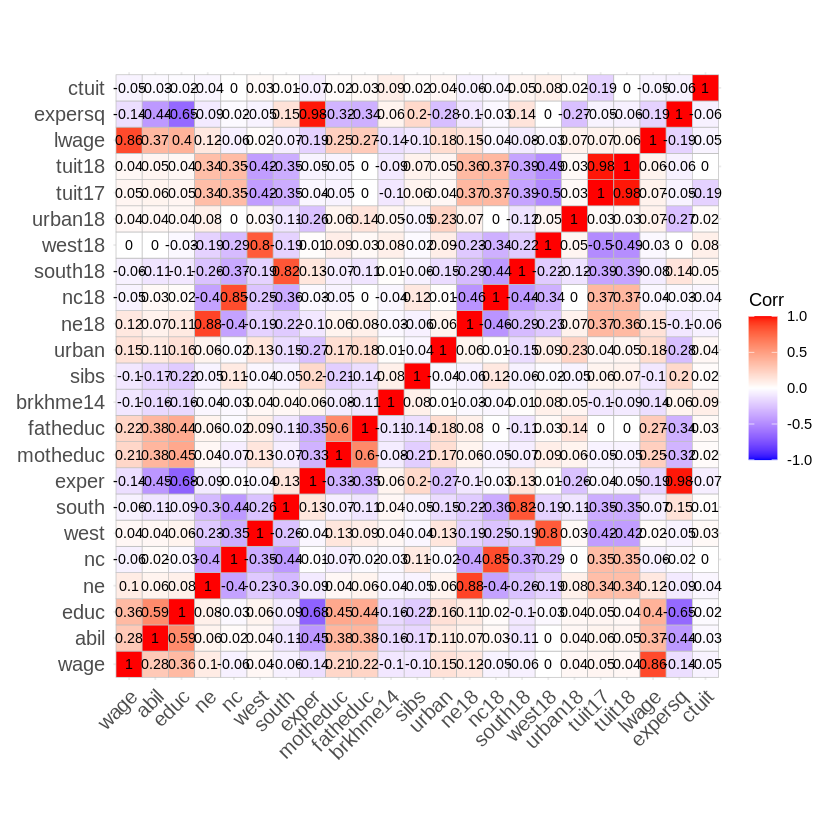

In [2]:
# Instalar paquetes
install.packages("wooldridge")
install.packages("ggcorrplot")
install.packages("lmtest")
install.packages("sandwich")
install.packages("car", dependencies = TRUE)

# Cargar librerías
library(wooldridge)
library(ggcorrplot)
library(lmtest)
library(sandwich)
library(car)

set.seed(1)
data(htv)
htv <- na.omit(htv)
matriz_corr <- cor(htv)
ggcorrplot(
  matriz_corr,
  type = "full",
  lab = TRUE,
  lab_size = 3
)
htv_filtrado <- subset(
  htv,
  select = -c(ne18, nc18, tuit17, lwage, expersq)
)

En la matriz de correlación se observan asociaciones altas entre algunas variables,
lo que puede generar problemas de multicolinealidad si se incluyen simultáneamente
en el modelo. Por este motivo, se eliminan ne18, nc18, tuit17, lwage y expersq.

La decisión se basa en que estas variables presentan alta correlación con otras
variables explicativas o representan transformaciones de variables ya incluidas.
Con esta selección se buscó evitar redundancia en la información y mejorar la estimación del modelo.

2. Realice un modelo de Regresión Lineal para las variables de esta base explicando
el salario. Identifique y elimine de la base las variables que individualmente no son relevantes
al 5% de significancia.

In [3]:
modelo_inicial <- lm(wage ~ ., data = htv_filtrado)
summary(modelo_inicial)


Call:
lm(formula = wage ~ ., data = htv_filtrado)

Residuals:
    Min      1Q  Median      3Q     Max 
-17.706  -4.377  -1.010   2.612  71.335 

Coefficients: (1 not defined because of singularities)
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -23.36404    3.59427  -6.500 1.17e-10 ***
abil          0.41854    0.13666   3.063  0.00224 ** 
educ          1.67509    0.16283  10.288  < 2e-16 ***
ne            1.00395    1.08439   0.926  0.35472    
nc           -0.71354    1.01789  -0.701  0.48344    
west          0.04498    1.25741   0.036  0.97147    
south              NA         NA      NA       NA    
exper         0.82719    0.11202   7.384 2.84e-13 ***
motheduc      0.02472    0.13561   0.182  0.85538    
fatheduc      0.12865    0.09419   1.366  0.17221    
brkhme14     -0.72774    0.64878  -1.122  0.26221    
sibs         -0.10950    0.13169  -0.832  0.40583    
urban         2.94273    0.65206   4.513 7.01e-06 ***
south18      -0.27209    1.08493  -0.251  0

In [4]:
htv_filtrado <- subset(
  htv_filtrado,
  select = -c(ne, nc, motheduc, fatheduc, brkhme14, sibs,
              south18, west18, tuit18, ctuit, south, west)
)

# Modelo corregido con variables relevantes
modelo <- lm(wage ~ ., data = htv_filtrado)

summary(modelo)


Call:
lm(formula = wage ~ ., data = htv_filtrado)

Residuals:
    Min      1Q  Median      3Q     Max 
-17.758  -4.516  -1.011   2.520  70.895 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -23.7739     3.1340  -7.586 6.52e-14 ***
abil          0.4785     0.1337   3.578  0.00036 ***
educ          1.7927     0.1549  11.574  < 2e-16 ***
exper         0.8326     0.1109   7.505 1.17e-13 ***
urban         3.1371     0.6403   4.900 1.09e-06 ***
urban18       1.5137     0.7565   2.001  0.04562 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 8.22 on 1224 degrees of freedom
Multiple R-squared:  0.1841,	Adjusted R-squared:  0.1807 
F-statistic: 55.22 on 5 and 1224 DF,  p-value: < 2.2e-16



Se estimó un modelo de regresión lineal para explicar wage (salario). Luego de revisar la significancia individual de las variables al 5%, se eliminaron aquellas con p-value mayor a 0,05: ne, nc, motheduc, fatheduc, brkhme14, sibs, south18, west18, tuit18, ctuit, south y west.

Las variables que permanecen en el modelo presentan evidencia estadística suficiente para explicar diferencias en el salario.

3. Realice nuevamente un modelo de regresión lineal con la nueva base


(a) ¿Existe heterocedasticidad? Realice el test que más le acomode y concluya.

In [5]:
bptest(modelo)


	studentized Breusch-Pagan test

data:  modelo
BP = 58.514, df = 5, p-value = 2.464e-11


(a)

Se aplicó el test de Breusch-Pagan para evaluar heterocedasticidad.

H0: Existe homocedasticidad.
H1: Existe heterocedasticidad.

Como el p-value es menor a 0,05, se rechaza la hipótesis nula. Por lo tanto, existe heterocedasticidad en el modelo. Esto indica que la varianza de los errores no es constante, por lo que los errores estándar tradicionales pueden no ser confiables.

(b) En caso de existir heterocedasticidad, encuentro los errores estandar robustos
de White ¿Alguna variable que dejo de ser significante individualmente al 5%?

In [6]:
coeftest(modelo, vcov = vcovHC(modelo, type = "HC0"))


t test of coefficients:

             Estimate Std. Error t value  Pr(>|t|)    
(Intercept) -23.77386    3.96121 -6.0017 2.569e-09 ***
abil          0.47854    0.10632  4.5009 7.412e-06 ***
educ          1.79274    0.21413  8.3722 < 2.2e-16 ***
exper         0.83260    0.12494  6.6638 4.025e-11 ***
urban         3.13710    0.48037  6.5306 9.582e-11 ***
urban18       1.51370    0.87057  1.7388   0.08233 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


(b)

Dado que existe heterocedasticidad, se corrigen los errores estándar usando
errores robustos de White. Esta corrección no cambia los coeficientes estimados,
pero sí modifica los errores estándar, los estadísticos t y los valores p.

Al comparar los resultados robustos con el modelo original, se observa que
urban18 deja de ser significativa individualmente al 5%. Esto muestra la importancia
de corregir la heterocedasticidad, porque una variable que parecía relevante con
errores estándar tradicionales puede dejar de serlo cuando se usa inferencia robusta.

(c) Interprete los resultados del Modelo. ¿Tiene significancia Global? Considere
que existe heterocedasticidad, utilizando la función waldtest con solo un modelo y errores
robustos.


In [7]:
m_full <- lm(wage ~ abil + educ + exper + urban + urban18, data = htv)

waldtest(
  m_full,
  vcov = vcovHC(m_full, type = "HC0"),
  test = "F"
)

,Res.Df,Df,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
1,1224,NA,NA,NA
2,1229,-5,37.81602,3.754581e-36


(c)

El modelo muestra que variables como educ, exper y abil tienen un efecto positivo sobre el salario, indicando que mayores niveles de educación, experiencia y habilidad se asocian con salarios más altos.

Para evaluar la significancia global se aplicó un test de Wald con errores robustos. Como el p-value es menor a 0,05, se rechaza la hipótesis nula y se concluye que el modelo tiene significancia global. Es decir, las variables incluidas explican conjuntamente el salario.


**BASE DE DATOS hprice2**

1. Realice una matriz de correlación entre las variables de la base, identificando
correlaciones altas, y eliminando, según criterio propio, una de las variables del par correlacionado.


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



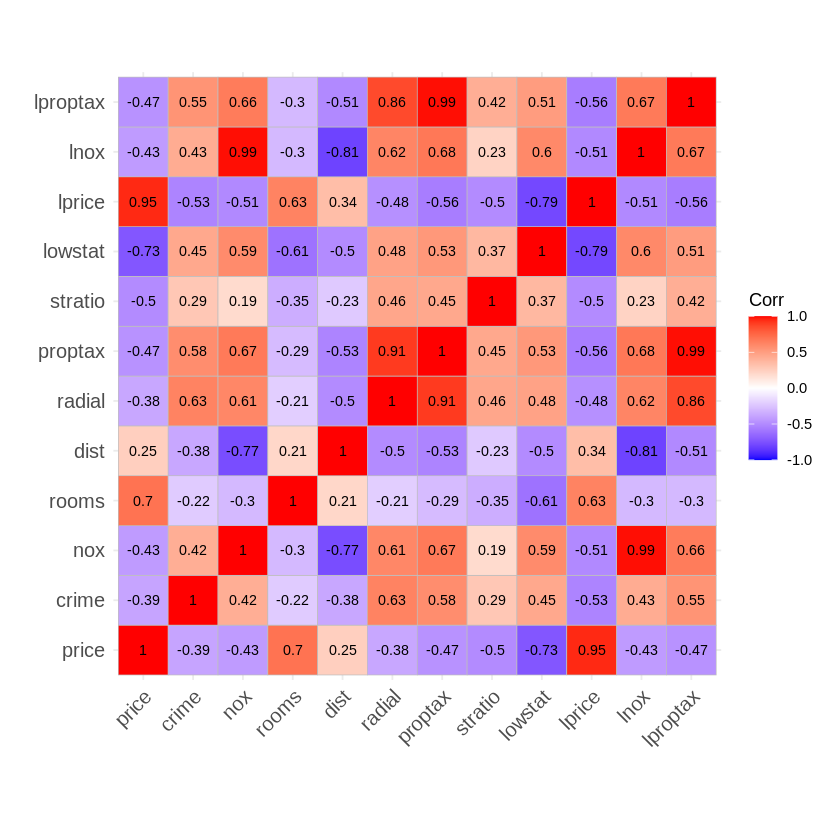

In [8]:
install.packages("wooldridge")
install.packages("ggcorrplot")
install.packages("lmtest")
install.packages("sandwich")

library(wooldridge)
library(ggcorrplot)
library(lmtest)
library(sandwich)

set.seed(1)

data("hprice2")
hprice2 <- na.omit(hprice2)

matriz_corr <- cor(hprice2)

ggcorrplot(
  matriz_corr,
  type = "full",
  lab = TRUE,
  lab_size = 3
)
hprice2_filtrado <- subset(
  hprice2,
  select = -c(lprice, lnox, lproptax)
)


Al revisar la matriz de correlación se ven tres pares con correlación casi perfecta: price con lprice (0.95), nox con lnox (0.99) y proptax con lproptax (0.99). Tiene sentido porque en cada caso una variable es simplemente el logaritmo de la otra, así que entregan la misma información. Para evitar problemas de multicolinealidad elimino las versiones en logaritmo (lprice, lnox y lproptax) y me quedo con las variables en nivel.

2. Realice un modelo de Regresión Lineal para las variables de esta base explicando
el salario. Identifique y elimine de la base las variables que individualmente no son relevantes
al 10% de significancia.

In [13]:
modelo <- lm(price ~ ., data = hprice2_filtrado)
summary(modelo)


Call:
lm(formula = price ~ ., data = hprice2_filtrado)

Residuals:
     Min       1Q   Median       3Q      Max 
-13096.0  -2988.4   -849.3   2063.6  27405.4 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 41533.99    5065.24   8.200 2.07e-15 ***
crime        -122.54      33.85  -3.621 0.000324 ***
nox         -1853.23     365.32  -5.073 5.54e-07 ***
rooms        4062.66     416.94   9.744  < 2e-16 ***
dist        -1231.39     167.96  -7.331 9.31e-13 ***
radial        293.17      65.95   4.445 1.08e-05 ***
proptax      -122.36      34.33  -3.564 0.000400 ***
stratio     -1102.70     125.89  -8.759  < 2e-16 ***
lowstat      -519.64      47.62 -10.912  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4953 on 497 degrees of freedom
Multiple R-squared:  0.7154,	Adjusted R-squared:  0.7108 
F-statistic: 156.1 on 8 and 497 DF,  p-value: < 2.2e-16


Estimé el modelo price. con la base ya filtrada. Mirando los p-value del summary, todas las variables resultan significativas al 10% (de hecho la menos significativa es proptax con un p-value cercano a 0.0004, y el resto queda por debajo de 0.001). Como ninguna supera el 10%, no elimino ninguna variable y la base se mantiene igual para las preguntas siguientes. El modelo tiene un R² de 0.7154.

3. Realice nuevamente un modelo de regresión lineal con la nueva base

(a) ¿Existe heterocedasticidad? Use test de White simplificado.

In [10]:
bptest(
  modelo,
  ~ fitted(modelo) + I(fitted(modelo)^2)
)


	studentized Breusch-Pagan test

data:  modelo
BP = 15.813, df = 2, p-value = 0.0003684


Al aplicar el test de White simplificado (Breusch-Pagan sobre los valores ajustados y su cuadrado). El p-value da alrededor de 0.0004, bastante por debajo de 0.05, así que rechazo la hipótesis nula de homocedasticidad. Concluyo que sí hay heterocedasticidad en el modelo.

(b) En caso de existir heterocedasticidad, encuentro los errores estandar robustos
de White ¿Alguna variable que dejo de ser significante individualmente al 5%?


In [11]:
coeftest(
  modelo,
  vcov = vcovHC(modelo, type = "HC0")
)


t test of coefficients:

             Estimate Std. Error t value  Pr(>|t|)    
(Intercept) 41533.992   7384.087  5.6248 3.104e-08 ***
crime        -122.544     24.292 -5.0447 6.380e-07 ***
nox         -1853.227    330.761 -5.6029 3.496e-08 ***
rooms        4062.658    753.102  5.3946 1.065e-07 ***
dist        -1231.388    187.471 -6.5684 1.285e-10 ***
radial        293.167     63.182  4.6401 4.461e-06 ***
proptax      -122.361     28.423 -4.3050 2.012e-05 ***
stratio     -1102.697    110.573 -9.9726 < 2.2e-16 ***
lowstat      -519.637     89.161 -5.8281 1.009e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Como existe heterocedasticidad, los errores estándar de la regresión original no son confiables, así que estimé los errores robustos de White con coeftest. Al comparar con el modelo original, ninguna variable deja de ser significativa al 5%: todas mantienen p-value bajo 0.001 incluso con los errores corregidos. O sea que la heterocedasticidad afecta la magnitud de los errores estándar pero no cambia las conclusiones de significancia individual.

(c) Interprete los resultados del Modelo. ¿Tiene significancia Global? Considere
que existe heterocedasticidad, utilizando la función waldtest con solo un modelo y errores
robustos.

In [12]:
waldtest(
  modelo,
  vcov = vcovHC(modelo, type = "HC0"),
  test = "F"
)


,Res.Df,Df,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
1,497,NA,NA,NA
2,505,-8,130.3504,7.454498e-117


El test de Wald con errores robustos permite evaluar la significancia global
del modelo considerando la presencia de heterocedasticidad.

H0: Todos los coeficientes explicativos son iguales a cero.
H1: Al menos una variable explicativa tiene efecto sobre price.

Si el p-value del test F robusto es menor a 0,05, se rechaza H0.
Esto significa que el modelo tiene significancia global, es decir,
las variables incluidas explican conjuntamente el precio de las viviendas.